# Taller CNN — AAIV 2026-II · MIAA-MCD
## Detección de somnolencia + localización del conductor

**Integrantes (2):**
- Luis Manuel Rojas Correa
- Dartunduaga (nombre completo)

**Competencia Kaggle:** [aaiv-2026-ii-taller-cnn-miaa-mcd](https://www.kaggle.com/competitions/aaiv-2026-ii-taller-cnn-miaa-mcd)

**Métricas oficiales:** Accuracy (clasificación) · Dice coefficient (bbox regression, con Dice = 2·IoU/(1+IoU)).

---

### Pipeline (columna vertebral)

```
§1 Setup ─▶ §2 EDA ─▶ §3 Split (nested) ─▶ §4 Dataset+albumentations
                                                    │
                         §5 Metrics/losses ◀────────┤
                         §6 CustomCNN               │
                         §7 build_pretrained() ─────┤
                                                    ▼
                         §8 train_one_config(cfg)  ← CORAZÓN reutilizable
                                                    │
                         §9 Experiments tracker  ◀──┤
                                                    ▼
        ┌───────────────┬───────────────┬───────────┼──────────────┐
        ▼               ▼               ▼           ▼              ▼
  §10 P1 CNN       §11 P2+3          §12 P4       §13 P5         §14 P6
  custom desde     hyperparam        augment      transfer       best +
  cero             sweeps ≥3         ablation     learning       interpret.
                                                                      │
                                                            §15 Inference+TTA+submission
```

### Directrices del taller (guían cada decisión)

1. **Fundamentar** cada decisión con papers / libros / docs oficiales / notebooks Kaggle.
2. **Comparar variantes** — no basta un modelo, la rúbrica exige comparación.
3. **Librerías oficiales** (`torch`, `torchvision`, `timm`, `albumentations`) — sin reinventar.
4. **Pipeline mantenible** — `train_one_config(cfg)` es la abstracción central.
5. **Reusar contexto** — ver [`docs/pipeline_design.md`](docs/pipeline_design.md) para el detalle completo del diseño.

---
## §1. Setup — imports, semilla, config global

**Fundamento:** reproducibilidad (semilla fija en todo el pipeline) + config centralizada (directriz 4).

In [1]:
import os, sys, random, json, time, math, warnings
from pathlib import Path
from typing import Tuple, List, Dict, Callable, Optional
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models
from torchvision.ops import generalized_box_iou_loss, box_iou

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupShuffleSplit
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# --- Semilla fija para reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Rutas ---
ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
IMG_DIR  = DATA_DIR / 'images'
OUT_DIR  = ROOT / 'outputs'; OUT_DIR.mkdir(exist_ok=True)
CKPT_DIR = ROOT / 'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)

# --- Constantes del problema ---
IMG_W, IMG_H = 1920, 1080
CLASSES = ['awake', 'drowsy']  # orden fijo: awake=0, drowsy=1
N_CLASSES = len(CLASSES)
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLS = {i: c for c, i in CLS2IDX.items()}

# --- Stats de normalización ---
# ImageNet stats — usar CON backbones preentrenados (mantiene warm-start)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
# Stats del train (calculadas en tools/eda) — usar con CustomCNN from scratch
TRAIN_MEAN = [0.4752, 0.4592, 0.4563]
TRAIN_STD  = [0.2500, 0.2351, 0.2157]

print(f"PyTorch    : {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"albumentat.: {A.__version__}")
print(f"timm       : {timm.__version__}")
print(f"Device     : {DEVICE}")
print(f"Root       : {ROOT}")

PyTorch    : 2.13.0+cu130
torchvision: 0.28.0+cu130
albumentat.: 2.0.8
timm       : 1.0.28
Device     : cpu
Root       : /home/luisrojas/Documents/universidad/IA/CompetenciaKaggle/MIA-RetoKaggle-Lrojas-Dartunduaga


---
## §2. EDA — Exploración de datos

Detalle completo en [`docs/pipeline_design.md`](docs/pipeline_design.md). Aquí solo se reproducen
los hallazgos clave para dejar constancia en las output cells.

In [2]:
df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')
df_sub   = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f"Train: {df_train.shape}  |  Test: {df_test.shape}  |  Sample submission: {df_sub.shape}")
print("\n--- Train head ---")
print(df_train.head())

Train: (420, 6)  |  Test: (106, 1)  |  Sample submission: (106, 6)

--- Train head ---
                                            filename   class  xmin  ymin  \
0  GOPR0492_MP4-230_jpg.rf.714121132f1b17cd0eadb6...  drowsy   792   380   
1  GOPR0492_MP4-488_jpg.rf.2971b413da07f25d05ba44...   awake   857   432   
2  GOPR0492_MP4-220_jpg.rf.564cb5e6e87965c6186c78...  drowsy   812   393   
3  GOPR0492_MP4-129_jpg.rf.12bda42acd227c8b665c95...  drowsy   710   357   
4  GOPR0492_MP4-399_jpg.rf.bfa4da2e417fae945145c7...  drowsy   805   409   

   xmax  ymax  
0  1171   981  
1  1202   833  
2  1128   861  
3  1087   956  
4  1115   853  


In [3]:
# Distribución de clases y bbox
df_train['w'] = df_train.xmax - df_train.xmin
df_train['h'] = df_train.ymax - df_train.ymin
df_train['cx'] = (df_train.xmin + df_train.xmax) / 2
df_train['cy'] = (df_train.ymin + df_train.ymax) / 2
df_train['aspect'] = df_train.w / df_train.h
df_train['area_frac'] = (df_train.w * df_train.h) / (IMG_W * IMG_H)

print("Distribución de clases:")
print(df_train['class'].value_counts())
print(f"\nBbox stats:")
print(df_train[['w','h','cx','cy','aspect','area_frac']].describe().round(2))

Distribución de clases:
class
awake     240
drowsy    180
Name: count, dtype: int64

Bbox stats:
            w       h       cx      cy  aspect  area_frac
count  420.00  420.00   420.00  420.00  420.00     420.00
mean   363.68  487.85   949.21  638.04    0.75       0.09
std     50.11   66.65    82.15   35.08    0.09       0.02
min    298.00  376.00   701.00  399.00    0.59       0.06
25%    329.00  437.00   901.38  619.88    0.69       0.07
50%    349.00  468.00   943.25  634.00    0.73       0.08
75%    384.00  530.25   985.12  651.12    0.81       0.09
max    558.00  776.00  1346.00  770.00    1.04       0.20


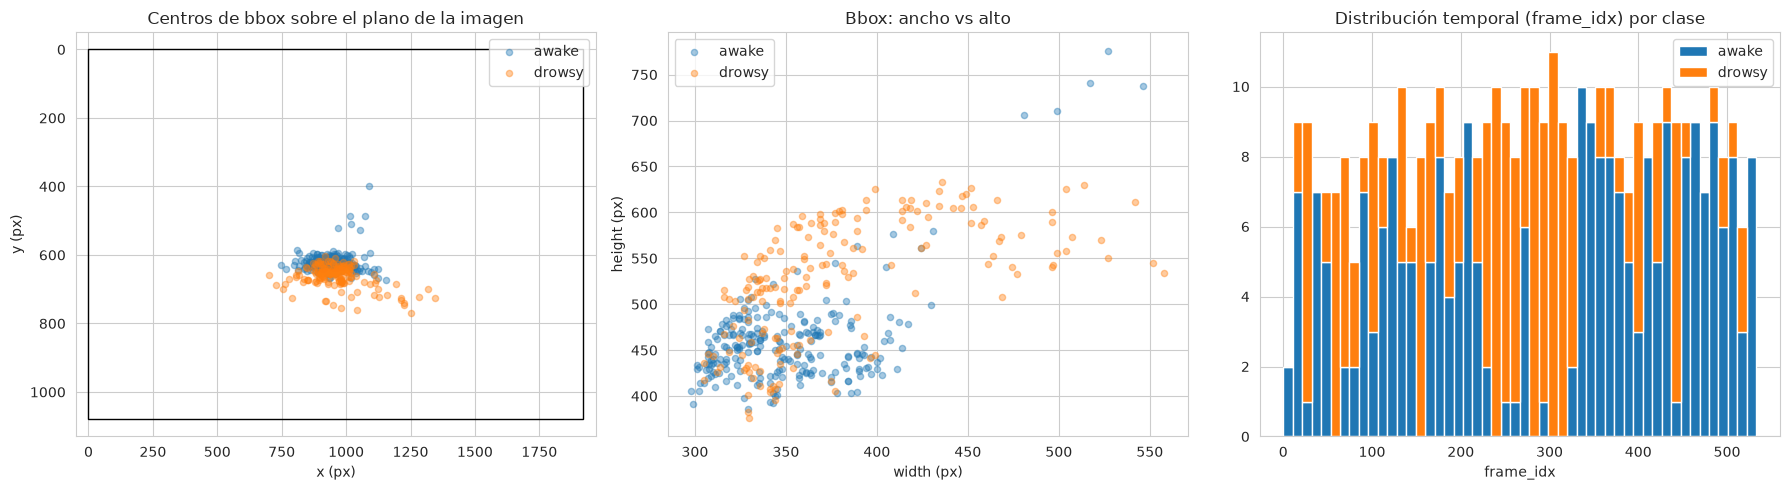

In [4]:
# Plot: centros de bbox, tamaños y distribución temporal por clase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls, color in [('awake', 'C0'), ('drowsy', 'C1')]:
    sub = df_train[df_train['class'] == cls]
    axes[0].scatter(sub.cx, sub.cy, alpha=0.4, s=20, label=cls, color=color)
    axes[1].scatter(sub.w, sub.h, alpha=0.4, s=20, label=cls, color=color)

axes[0].add_patch(plt.Rectangle((0,0), IMG_W, IMG_H, fill=False, edgecolor='black'))
axes[0].set_xlim(-50, IMG_W+50); axes[0].set_ylim(IMG_H+50, -50)
axes[0].set_title('Centros de bbox sobre el plano de la imagen'); axes[0].legend()
axes[0].set_xlabel('x (px)'); axes[0].set_ylabel('y (px)')

axes[1].set_title('Bbox: ancho vs alto'); axes[1].legend()
axes[1].set_xlabel('width (px)'); axes[1].set_ylabel('height (px)')

df_train['frame_idx'] = df_train.filename.str.extract(r'MP4-(\d+)').astype(int)
awake_f = df_train[df_train['class']=='awake'].frame_idx
drowsy_f = df_train[df_train['class']=='drowsy'].frame_idx
axes[2].hist([awake_f, drowsy_f], bins=50, label=['awake','drowsy'], stacked=True)
axes[2].set_title('Distribución temporal (frame_idx) por clase'); axes[2].legend()
axes[2].set_xlabel('frame_idx')

plt.tight_layout(); plt.show()

**Hallazgos clave del EDA:**
- Imágenes 100% consistentes 1920×1080 RGB, un solo bbox por imagen, sin errores de anotación.
- Conductor **casi siempre centrado en zona central-inferior** (cx std=8.7%, cy std=5.5%).
- Ligero desbalance: awake=240 (57%), drowsy=180 (43%) → usar `class_weight`.
- **Test frames INTERLEAVED temporalmente con train** (mismo video GOPR0492) — el organizador no separó por escena, la métrica del leaderboard mide "generalización cercana".

---
## §3. Split train/val — estrategia NESTED (two-stage)

**Justificación** (ver `pipeline_design.md` §2): con 420 muestras un holdout único varía ±5-8% por sampling bias
([PMC guide](https://pmc.ncbi.nlm.nih.gov/articles/PMC10388213/), [Raschka arxiv:1811.12808](https://arxiv.org/pdf/1811.12808)).

- **Etapa exploratoria** (~15 experimentos): single stratified split 80/20 fijo (rápido y comparable).
- **Etapa final** (top-3 candidatos): StratifiedKFold k=5 sobre esos 3, promediando métricas.
- **Anti-fuga:** `stratify=y`, `random_state=SEED`. Los stats de normalización se calculan **sólo sobre train**.

In [5]:
def make_split(df: pd.DataFrame, test_size: float = 0.2, seed: int = SEED
               ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Split estratificado por clase — devuelve (df_train, df_val) con reset_index."""
    df_tr, df_val = train_test_split(
        df, test_size=test_size, stratify=df['class'], random_state=seed
    )
    return df_tr.reset_index(drop=True), df_val.reset_index(drop=True)


def make_kfold(df: pd.DataFrame, n_splits: int = 5, seed: int = SEED):
    """Genera splits StratifiedKFold — devuelve lista de tuplas (df_train, df_val)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for tr_idx, val_idx in skf.split(df, df['class']):
        folds.append((df.iloc[tr_idx].reset_index(drop=True),
                      df.iloc[val_idx].reset_index(drop=True)))
    return folds


# --- Split principal (para exploración) ---
df_tr, df_val = make_split(df_train)
print(f"Train n={len(df_tr)}, Val n={len(df_val)}")
print("Balance clases train:", df_tr['class'].value_counts().to_dict())
print("Balance clases val  :", df_val['class'].value_counts().to_dict())

# --- Class weights para CrossEntropy (Raschka cap 6) ---
n_total = len(df_tr)
class_counts = df_tr['class'].value_counts().to_dict()
class_weights = torch.tensor(
    [n_total / (N_CLASSES * class_counts[c]) for c in CLASSES],
    dtype=torch.float32
)
print(f"\nClass weights (para CE): {dict(zip(CLASSES, class_weights.tolist()))}")

Train n=336, Val n=84
Balance clases train: {'awake': 192, 'drowsy': 144}
Balance clases val  : {'awake': 48, 'drowsy': 36}

Class weights (para CE): {'awake': 0.875, 'drowsy': 1.1666666269302368}


---
## §4. Data pipeline — Dataset + albumentations

**Decisiones:**
- **Bbox format interno:** `(cx, cy, w, h)` normalizado en [0, 1] (convención YOLO/DETR).
  Al inferir se convierte de vuelta a `(xmin, ymin, xmax, ymax)` en pixels para el CSV.
- **Albumentations** con `BboxParams(format='pascal_voc')` reescala bboxes automáticamente ante augmentations geométricas.
- **Resize** 224×224 (compatible con backbones ImageNet).
- **Normalización** por defecto `ImageNet stats` (para pretrained); pasar `use_imagenet_stats=False` para CustomCNN.

**Fuentes:** [albumentations bbox docs](https://albumentations.ai/docs/3-basic-usage/bounding-boxes-augmentations/),
Chollet cap 12 (bbox norm 0-1), Géron cap 14 (multitask heads).

In [6]:
def xyxy_to_cxcywh_norm(bbox_xyxy: List[float], img_w: int = IMG_W, img_h: int = IMG_H) -> List[float]:
    """Pascal VOC absoluto (xmin,ymin,xmax,ymax) → (cx,cy,w,h) normalizado a [0,1]."""
    x1, y1, x2, y2 = bbox_xyxy
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return [cx, cy, w, h]


def cxcywh_norm_to_xyxy(bbox_cxcywh_norm: torch.Tensor, img_w: int = IMG_W, img_h: int = IMG_H) -> torch.Tensor:
    """Inverso: (cx,cy,w,h) norm → (xmin,ymin,xmax,ymax) pixels. Acepta batches (N,4)."""
    cx, cy, w, h = bbox_cxcywh_norm.unbind(-1)
    x1 = (cx - w/2) * img_w
    y1 = (cy - h/2) * img_h
    x2 = (cx + w/2) * img_w
    y2 = (cy + h/2) * img_h
    return torch.stack([x1, y1, x2, y2], dim=-1)


def build_transforms(input_size: int = 224,
                     aug_level: str = 'basic',
                     use_imagenet_stats: bool = True) -> A.Compose:
    """
    aug_level: 'none' | 'basic' | 'strong'
    - none:   solo resize + normalize (baseline)
    - basic:  + HorizontalFlip + RandomBrightnessContrast (Chollet cap 8)
    - strong: + ShiftScaleRotate + HueSaturation + GaussNoise + MotionBlur
             (frames GoPro tienen ese tipo de ruido / iluminación variable)
    Referencia: albumentations docs oficiales.
    """
    mean = IMAGENET_MEAN if use_imagenet_stats else TRAIN_MEAN
    std  = IMAGENET_STD  if use_imagenet_stats else TRAIN_STD

    ops: List = []
    if aug_level in ('basic', 'strong'):
        ops.append(A.HorizontalFlip(p=0.5))
        ops.append(A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5))
    if aug_level == 'strong':
        ops.append(A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5))
        ops.append(A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5))
        ops.append(A.GaussNoise(var_limit=(10, 30), p=0.3))
        ops.append(A.MotionBlur(blur_limit=5, p=0.3))
    ops += [
        A.Resize(input_size, input_size),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ]
    return A.Compose(
        ops,
        bbox_params=A.BboxParams(
            format='pascal_voc',       # trabajamos internamente en pascal_voc (xmin,ymin,xmax,ymax)
            label_fields=['class_labels'],
            min_visibility=0.3,        # descarta bbox recortadas al <30% (raro en este dataset)
        ),
    )


class DrowsyDataset(Dataset):
    """
    Dataset multitask:
      __getitem__ → (img_tensor CxHxW, label_int, bbox_cxcywh_norm (4,))

    df debe tener columnas: filename, class, xmin, ymin, xmax, ymax.
    is_test=True hace que el label y el bbox sean placeholders (para inferencia).
    """
    def __init__(self, df: pd.DataFrame, img_dir: Path,
                 transform: A.Compose, is_test: bool = False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.is_test = is_test

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = cv2.imread(str(self.img_dir / row['filename']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV lee BGR → convertir a RGB

        if self.is_test:
            # bbox dummy centrada; será ignorada en inferencia
            bboxes = [[IMG_W*0.4, IMG_H*0.4, IMG_W*0.6, IMG_H*0.6]]
            class_labels = ['awake']
        else:
            bboxes = [[row.xmin, row.ymin, row.xmax, row.ymax]]
            class_labels = [row['class']]

        out = self.transform(image=img, bboxes=bboxes, class_labels=class_labels)
        img_t = out['image']

        if self.is_test:
            return img_t, row['filename']

        # el bbox augmentado puede quedar como lista vacía si min_visibility filtra; fallback = original
        aug_bbox = out['bboxes'][0] if out['bboxes'] else bboxes[0]
        # aug_bbox está en pascal_voc RELATIVO al tamaño del resize (después de A.Resize)
        # tenemos que reescalar a coords en la imagen resizeada; A.Resize ya ajusta el bbox.
        # Convertimos a cxcywh normalizado usando el tamaño de la imagen resizeada.
        H, W = img_t.shape[-2:]  # C,H,W tensor
        cxcywh_norm = torch.tensor(
            xyxy_to_cxcywh_norm(list(aug_bbox), img_w=W, img_h=H),
            dtype=torch.float32,
        )
        label = torch.tensor(CLS2IDX[out['class_labels'][0]], dtype=torch.long)
        return img_t, label, cxcywh_norm


# --- Test rápido del pipeline ---
_tr_transform  = build_transforms(input_size=224, aug_level='basic', use_imagenet_stats=True)
_val_transform = build_transforms(input_size=224, aug_level='none',  use_imagenet_stats=True)
_ds = DrowsyDataset(df_tr, IMG_DIR, _tr_transform)
_img, _label, _bbox = _ds[0]
print(f"img tensor: shape={_img.shape}, dtype={_img.dtype}, range=[{_img.min():.2f}, {_img.max():.2f}]")
print(f"label     : {_label.item()} ({IDX2CLS[_label.item()]})")
print(f"bbox_norm : {_bbox.tolist()}  (cx, cy, w, h) en [0,1]")

img tensor: shape=torch.Size([3, 224, 224]), dtype=torch.float32, range=[-1.64, 2.64]
label     : 0 (awake)
bbox_norm : [0.5252604484558105, 0.5833333134651184, 0.17656248807907104, 0.45000001788139343]  (cx, cy, w, h) en [0,1]


---
## §5. Métricas + losses + EarlyStopping

**Referencias:**
- IoU: Chollet cap 12 [`chapter12_object-detection.ipynb`](references/deep-learning-with-python-notebooks/chapter12_object-detection.ipynb) L520-540.
- Dice = 2·IoU/(1+IoU) — derivación directa (los libros no lo traen explícito para bbox).
- Loss bbox estilo DETR: `1·SmoothL1 + 2·GIoU` — DETR paper (Carion et al. 2020).
- EarlyStopping: [Keras docs](https://keras.io/api/callbacks/early_stopping/), [MLM guide](https://machinelearningmastery.com/how-to-stop-training-deep-neural-networks-at-the-right-time-using-early-stopping/).

In [7]:
def bbox_iou(pred_cxcywh: torch.Tensor, true_cxcywh: torch.Tensor,
             eps: float = 1e-7) -> torch.Tensor:
    """
    IoU batched entre dos tensores (N,4) en formato (cx,cy,w,h). Todo en [0,1] o pixels indistinto.
    """
    def _to_xyxy(b):
        cx, cy, w, h = b.unbind(-1)
        return torch.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dim=-1)
    p, t = _to_xyxy(pred_cxcywh), _to_xyxy(true_cxcywh)
    x1 = torch.max(p[..., 0], t[..., 0])
    y1 = torch.max(p[..., 1], t[..., 1])
    x2 = torch.min(p[..., 2], t[..., 2])
    y2 = torch.min(p[..., 3], t[..., 3])
    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area_p = (p[..., 2] - p[..., 0]) * (p[..., 3] - p[..., 1])
    area_t = (t[..., 2] - t[..., 0]) * (t[..., 3] - t[..., 1])
    union = area_p + area_t - inter + eps
    return inter / union


def bbox_dice(pred_cxcywh: torch.Tensor, true_cxcywh: torch.Tensor) -> torch.Tensor:
    """Dice coefficient = 2·IoU/(1+IoU). Monotónica en IoU."""
    iou = bbox_iou(pred_cxcywh, true_cxcywh)
    return 2 * iou / (1 + iou)


class MultitaskLoss(nn.Module):
    """
    Loss combinada: L = w_cls · CE + w_bbox · (SmoothL1 + λ_giou · GIoU_loss)
    Config default estilo DETR (SmoothL1 estable + GIoU mejora convergencia geométrica).
    """
    def __init__(self, w_cls: float = 1.0, w_bbox: float = 5.0,
                 lambda_giou: float = 2.0, class_weights: Optional[torch.Tensor] = None):
        super().__init__()
        self.w_cls = w_cls
        self.w_bbox = w_bbox
        self.lambda_giou = lambda_giou
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.smooth_l1 = nn.SmoothL1Loss()

    def forward(self, logits: torch.Tensor, bbox_pred: torch.Tensor,
                labels: torch.Tensor, bbox_true: torch.Tensor) -> Dict[str, torch.Tensor]:
        loss_cls = self.ce(logits, labels)
        loss_l1  = self.smooth_l1(bbox_pred, bbox_true)
        # GIoU loss requiere xyxy en pixels o en [0,1] (invariant); usamos [0,1] via cxcywh_norm
        pred_xyxy = cxcywh_norm_to_xyxy(bbox_pred, img_w=1, img_h=1)
        true_xyxy = cxcywh_norm_to_xyxy(bbox_true, img_w=1, img_h=1)
        loss_giou = generalized_box_iou_loss(pred_xyxy, true_xyxy, reduction='mean')
        loss_bbox = loss_l1 + self.lambda_giou * loss_giou
        total = self.w_cls * loss_cls + self.w_bbox * loss_bbox
        return dict(total=total, cls=loss_cls, bbox=loss_bbox, l1=loss_l1, giou=loss_giou)


class EarlyStopping:
    """
    Monitorea `val_total_loss` (o cualquier métrica escalar). patience=12 recomendada para dataset chico.
    Uso:
      es = EarlyStopping(patience=12, min_delta=1e-3, mode='min')
      for epoch in range(max_epochs):
          ...
          if es.step(val_loss):
              break
    """
    def __init__(self, patience: int = 12, min_delta: float = 1e-3, mode: str = 'min'):
        assert mode in ('min', 'max')
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = math.inf if mode == 'min' else -math.inf
        self.counter = 0
        self.best_epoch = -1

    def step(self, value: float) -> bool:
        improved = (self.mode == 'min' and value < self.best - self.min_delta) or \
                   (self.mode == 'max' and value > self.best + self.min_delta)
        if improved:
            self.best = value
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


# --- Sanity check de metrics ---
_bbox_true = torch.tensor([[0.5, 0.5, 0.3, 0.4]])   # cxcywh en [0,1]
_bbox_pred = torch.tensor([[0.5, 0.5, 0.3, 0.4]])
print(f"IoU(identical)  = {bbox_iou(_bbox_pred, _bbox_true).item():.4f}   (esperado 1.0)")
print(f"Dice(identical) = {bbox_dice(_bbox_pred, _bbox_true).item():.4f}  (esperado 1.0)")

_bbox_pred2 = torch.tensor([[0.6, 0.5, 0.3, 0.4]])  # desplazada
iou2 = bbox_iou(_bbox_pred2, _bbox_true).item()
dice2 = bbox_dice(_bbox_pred2, _bbox_true).item()
print(f"IoU(shifted)    = {iou2:.4f}  |  Dice(shifted) = {dice2:.4f}")

IoU(identical)  = 1.0000   (esperado 1.0)
Dice(identical) = 1.0000  (esperado 1.0)
IoU(shifted)    = 0.5000  |  Dice(shifted) = 0.6667


---
## §6. CustomCNN — Backbone desde cero (Punto 1 rúbrica)

**Arquitectura:** 4 bloques `Conv3x3(pad=1) → BN → ReLU → MaxPool2x2 → Dropout(0.5)`, canales 32→64→128→256,
seguidos de **GlobalAveragePooling** (menos parámetros que Flatten, previene overfit).

**Justificaciones citables en sustentación:**
- Kernel 3×3 padding 1: **VGG-style, Simonyan & Zisserman 2014** (arxiv:1409.1556) — bloques homogéneos.
- BatchNorm: **Ioffe & Szegedy 2015** (arxiv:1502.03167) — estabiliza gradientes, permite LR mayor.
- Dropout 0.5: **Srivastava et al. 2014** — apropiado con dataset chico.
- GAP: **Chollet cap 9**, **Lin et al. Network-in-Network 2013** (arxiv:1312.4400) — 10× menos params.
- He/Kaiming init: **Géron cap 11**, requerido por ReLU para preservar varianza.
- Basado en el patrón `ch14_part2.py:289-306` de Raschka.

In [8]:
class CustomCNN(nn.Module):
    """
    Multitask CNN from scratch:
        Input (B,3,H,W)
          → 4× [Conv3-BN-ReLU-MaxPool2-Dropout] canales 32→64→128→256
          → GlobalAvgPool
          → head_cls: Linear(256, 2)
          → head_bbox: Linear(256, 4) + Sigmoid  (bbox cxcywh normalizado a [0,1])
    """
    def __init__(self, n_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32, dropout),
            self._block(32,  64, dropout),
            self._block(64, 128, dropout),
            self._block(128, 256, dropout),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)  # GAP → (B, 256, 1, 1)
        self.head_cls  = nn.Linear(256, n_classes)
        self.head_bbox = nn.Sequential(nn.Linear(256, 4), nn.Sigmoid())  # cxcywh en [0,1]
        self._init_weights()

    @staticmethod
    def _block(in_c: int, out_c: int, dropout: float) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def _init_weights(self):
        # He/Kaiming (Géron cap 11)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        feat = self.features(x)          # (B, 256, H/16, W/16)
        pooled = self.pool(feat).flatten(1)  # (B, 256)
        logits = self.head_cls(pooled)   # (B, 2)
        bbox   = self.head_bbox(pooled)  # (B, 4) en [0,1]
        return logits, bbox


# --- Sanity check ---
_model = CustomCNN()
_x = torch.randn(2, 3, 224, 224)
_logits, _bbox = _model(_x)
_n_params = sum(p.numel() for p in _model.parameters())
print(f"CustomCNN — output: logits {tuple(_logits.shape)}, bbox {tuple(_bbox.shape)}")
print(f"  params: {_n_params/1e6:.2f}M")

CustomCNN — output: logits (2, 2), bbox (2, 4)
  params: 0.39M


---
## §7. Backbones preentrenados (Punto 5 rúbrica)

**3 backbones ligeros** (más informativo que 2 profundos con 336 samples + CPU
— [Lightweight benchmark arxiv:2505.03303](https://arxiv.org/html/2505.03303v1)):

| Backbone | Params | Fuente / paper |
|---|---|---|
| `resnet18` (torchvision) | 11M | He et al. 2015 arxiv:1512.03385 |
| `mobilenet_v3_small` (torchvision) | 2.5M | Howard et al. 2019 arxiv:1905.02244 |
| `efficientnet_b0` (timm) | 5.3M | Tan & Le 2019 arxiv:1905.11946 |

**Estrategia freeze/unfreeze en 2 fases** (Chollet cap 8, [TF tutorial](https://www.tensorflow.org/tutorials/images/transfer_learning)):
- **Fase A:** backbone congelado, entrenar solo heads (~10 epochs, LR=1e-3).
- **Fase B:** descongelar último stage, LR diferencial (backbone LR = head LR / 10), otros 15-20 epochs con early stopping.

In [9]:
class MultitaskWrapper(nn.Module):
    """Backbone (feature extractor) → GAP → head_cls + head_bbox."""
    def __init__(self, backbone: nn.Module, feat_dim: int,
                 n_classes: int = 2, dropout_head: float = 0.3):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout_head)
        self.head_cls  = nn.Linear(feat_dim, n_classes)
        self.head_bbox = nn.Sequential(nn.Linear(feat_dim, 4), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        feat = self.backbone(x)
        if feat.ndim == 4:
            feat = self.pool(feat).flatten(1)
        feat = self.dropout(feat)
        return self.head_cls(feat), self.head_bbox(feat)


def build_pretrained(name: str, n_classes: int = 2,
                     dropout_head: float = 0.3, freeze: bool = True) -> MultitaskWrapper:
    """
    Construye backbone preentrenado con heads multitask.
    name ∈ {'resnet18', 'mobilenet_v3_small', 'efficientnet_b0'}
    freeze: si True, backbone.parameters() se congelan (fase A).
            Para descongelar último stage (fase B) usar unfreeze_last_stage() abajo.
    """
    if name == 'resnet18':
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
    elif name == 'mobilenet_v3_small':
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        feat_dim = m.classifier[0].in_features
        m.classifier = nn.Identity()
    elif name == 'efficientnet_b0':
        m = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0, global_pool='')
        feat_dim = m.num_features
    else:
        raise ValueError(f"Backbone desconocido: {name}. Opciones: resnet18, mobilenet_v3_small, efficientnet_b0")

    if freeze:
        for p in m.parameters():
            p.requires_grad = False

    return MultitaskWrapper(m, feat_dim=feat_dim, n_classes=n_classes, dropout_head=dropout_head)


def unfreeze_last_stage(model: MultitaskWrapper, backbone_name: str) -> None:
    """Descongela el último stage del backbone (fase B fine-tuning parcial)."""
    if backbone_name == 'resnet18':
        for p in model.backbone.layer4.parameters(): p.requires_grad = True
    elif backbone_name == 'mobilenet_v3_small':
        # Últimos 3 bloques
        for p in model.backbone.features[-3:].parameters(): p.requires_grad = True
    elif backbone_name == 'efficientnet_b0':
        for p in model.backbone.blocks[-2:].parameters(): p.requires_grad = True


# --- Sanity check de los 3 backbones ---
for name in ['resnet18', 'mobilenet_v3_small', 'efficientnet_b0']:
    m = build_pretrained(name)
    n_total = sum(p.numel() for p in m.parameters())
    n_trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    logits, bbox = m(_x)
    print(f"{name:22s}  params total={n_total/1e6:>5.2f}M  entrenables={n_trainable/1e3:>5.1f}k  "
          f"→ logits {tuple(logits.shape)}, bbox {tuple(bbox.shape)}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/luisrojas/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  1%|          | 256k/44.7M [00:00<00:22, 2.09MB/s]

  2%|▏         | 896k/44.7M [00:00<00:10, 4.34MB/s]

  4%|▍         | 1.88M/44.7M [00:00<00:06, 6.79MB/s]

...

100%|██████████| 9.83M/9.83M [00:01<00:00, 9.17MB/s]

mobilenet_v3_small      params total= 0.93M  entrenables=  3.5k  → logits (2, 2), bbox (2, 4)


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

efficientnet_b0         params total= 4.02M  entrenables=  7.7k  → logits (2, 2), bbox (2, 4)


---
## §8. `train_one_config(cfg)` — CORAZÓN del pipeline

**Directriz 4:** cada experimento es una llamada a esta función con distinto `cfg` dict.
Los resultados se acumulan en `EXPERIMENTS_LOG` (§9) para el análisis final del punto 6.

In [10]:
@dataclass
class ExpConfig:
    """Config completa de un experimento. Cambiar aquí es cambiar el experimento."""
    name: str
    model_kind: str = 'custom'            # 'custom' | 'resnet18' | 'mobilenet_v3_small' | 'efficientnet_b0'
    input_size: int = 224
    batch_size: int = 32
    lr_head: float = 1e-3
    lr_backbone: float = 1e-4             # solo se usa en fase B
    weight_decay: float = 5e-4
    optimizer: str = 'adamw'              # 'adam' | 'adamw' | 'sgd'
    scheduler: str = 'cosine'             # 'cosine' | 'step' | 'none'
    bbox_loss_weight: float = 5.0
    lambda_giou: float = 2.0
    aug_level: str = 'basic'              # 'none' | 'basic' | 'strong'
    dropout_head: float = 0.3
    use_class_weights: bool = True
    freeze_epochs: int = 10                # fase A (feature extraction) — solo pretrained
    finetune_epochs: int = 20              # fase B (unfreeze last stage) — solo pretrained
    total_epochs: int = 30                 # CustomCNN entrena de una sola vez
    early_stopping_patience: int = 12
    seed: int = SEED
    num_workers: int = 2


def make_optimizer(model: nn.Module, cfg: ExpConfig, param_groups=None):
    if param_groups is None:
        param_groups = [{'params': [p for p in model.parameters() if p.requires_grad]}]
    if cfg.optimizer == 'adam':
        return torch.optim.Adam(param_groups, lr=cfg.lr_head, weight_decay=cfg.weight_decay)
    if cfg.optimizer == 'adamw':
        return torch.optim.AdamW(param_groups, lr=cfg.lr_head, weight_decay=cfg.weight_decay)
    if cfg.optimizer == 'sgd':
        return torch.optim.SGD(param_groups, lr=cfg.lr_head, momentum=0.9, weight_decay=cfg.weight_decay)
    raise ValueError(cfg.optimizer)


def make_scheduler(optimizer, cfg: ExpConfig, n_epochs: int):
    if cfg.scheduler == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    if cfg.scheduler == 'step':
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    return None


def train_epoch(model, loader, loss_fn, optimizer, device) -> Dict[str, float]:
    model.train()
    totals = dict(loss=0.0, cls=0.0, bbox=0.0, acc=0.0, dice=0.0)
    n = 0
    for img, label, bbox in loader:
        img, label, bbox = img.to(device), label.to(device), bbox.to(device)
        logits, bbox_pred = model(img)
        losses = loss_fn(logits, bbox_pred, label, bbox)
        optimizer.zero_grad()
        losses['total'].backward()
        optimizer.step()
        bs = img.size(0); n += bs
        totals['loss'] += losses['total'].item() * bs
        totals['cls']  += losses['cls'].item()   * bs
        totals['bbox'] += losses['bbox'].item()  * bs
        totals['acc']  += (logits.argmax(1) == label).float().sum().item()
        totals['dice'] += bbox_dice(bbox_pred, bbox).sum().item()
    return {k: v / n for k, v in totals.items()}


@torch.no_grad()
def eval_epoch(model, loader, loss_fn, device) -> Dict[str, float]:
    model.eval()
    totals = dict(loss=0.0, cls=0.0, bbox=0.0, acc=0.0, dice=0.0)
    n = 0
    for img, label, bbox in loader:
        img, label, bbox = img.to(device), label.to(device), bbox.to(device)
        logits, bbox_pred = model(img)
        losses = loss_fn(logits, bbox_pred, label, bbox)
        bs = img.size(0); n += bs
        totals['loss'] += losses['total'].item() * bs
        totals['cls']  += losses['cls'].item()   * bs
        totals['bbox'] += losses['bbox'].item()  * bs
        totals['acc']  += (logits.argmax(1) == label).float().sum().item()
        totals['dice'] += bbox_dice(bbox_pred, bbox).sum().item()
    return {k: v / n for k, v in totals.items()}


def train_one_config(cfg: ExpConfig,
                     df_train_split: pd.DataFrame,
                     df_val_split: pd.DataFrame,
                     verbose: bool = True) -> Dict:
    """
    Entrena un experimento entero según cfg. Devuelve dict con history + best metrics + ckpt path.
    Para pretrained: entrena en 2 fases (freeze → unfreeze last stage).
    Para CustomCNN: entrena en una sola fase de `total_epochs`.
    """
    # Reproducibilidad
    torch.manual_seed(cfg.seed); np.random.seed(cfg.seed); random.seed(cfg.seed)

    # Data
    use_imagenet_stats = (cfg.model_kind != 'custom')
    tr_tf  = build_transforms(cfg.input_size, cfg.aug_level, use_imagenet_stats)
    val_tf = build_transforms(cfg.input_size, 'none',        use_imagenet_stats)
    tr_ds  = DrowsyDataset(df_train_split, IMG_DIR, tr_tf)
    val_ds = DrowsyDataset(df_val_split,   IMG_DIR, val_tf)
    tr_ld  = DataLoader(tr_ds,  batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.num_workers, drop_last=True)
    val_ld = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=cfg.num_workers)

    # Modelo
    if cfg.model_kind == 'custom':
        model = CustomCNN(dropout=cfg.dropout_head)
    else:
        model = build_pretrained(cfg.model_kind, dropout_head=cfg.dropout_head, freeze=True)
    model = model.to(DEVICE)

    # Loss
    cw = class_weights.to(DEVICE) if cfg.use_class_weights else None
    loss_fn = MultitaskLoss(
        w_cls=1.0, w_bbox=cfg.bbox_loss_weight,
        lambda_giou=cfg.lambda_giou, class_weights=cw,
    )

    history = []
    best = dict(val_loss=math.inf, val_acc=0.0, val_dice=0.0, epoch=-1)
    ckpt_path = CKPT_DIR / f"{cfg.name}.pt"

    def _run_phase(n_epochs: int, phase_label: str, opt, sched, es):
        nonlocal best
        for ep in range(n_epochs):
            tr_metrics  = train_epoch(model, tr_ld,  loss_fn, opt, DEVICE)
            val_metrics = eval_epoch (model, val_ld, loss_fn, DEVICE)
            if sched is not None:
                sched.step()
            row = dict(phase=phase_label, epoch=ep,
                       **{f'train_{k}': v for k, v in tr_metrics.items()},
                       **{f'val_{k}':   v for k, v in val_metrics.items()})
            history.append(row)
            if verbose:
                print(f"  [{phase_label} ep{ep+1:>2}/{n_epochs}] "
                      f"train loss={tr_metrics['loss']:.3f} acc={tr_metrics['acc']:.3f} dice={tr_metrics['dice']:.3f}  |  "
                      f"val loss={val_metrics['loss']:.3f} acc={val_metrics['acc']:.3f} dice={val_metrics['dice']:.3f}")
            if val_metrics['loss'] < best['val_loss']:
                best = dict(val_loss=val_metrics['loss'], val_acc=val_metrics['acc'],
                            val_dice=val_metrics['dice'], epoch=len(history)-1)
                torch.save(model.state_dict(), ckpt_path)
            if es.step(val_metrics['loss']):
                if verbose:
                    print(f"  ↳ early stopping @ep{ep+1} (patience={cfg.early_stopping_patience})")
                break

    if cfg.model_kind == 'custom':
        opt = make_optimizer(model, cfg)
        sched = make_scheduler(opt, cfg, cfg.total_epochs)
        es = EarlyStopping(patience=cfg.early_stopping_patience)
        _run_phase(cfg.total_epochs, 'train', opt, sched, es)
    else:
        # FASE A — feature extraction (backbone congelado)
        opt_a = make_optimizer(model, cfg)  # solo params entrenables (heads)
        sched_a = make_scheduler(opt_a, cfg, cfg.freeze_epochs)
        es_a = EarlyStopping(patience=cfg.early_stopping_patience)
        _run_phase(cfg.freeze_epochs, 'A(feat)', opt_a, sched_a, es_a)
        # FASE B — unfreeze último stage + LR diferencial
        unfreeze_last_stage(model, cfg.model_kind)
        opt_b = torch.optim.AdamW([
            {'params': [p for p in model.backbone.parameters() if p.requires_grad],
             'lr': cfg.lr_backbone},
            {'params': list(model.head_cls.parameters()) + list(model.head_bbox.parameters()),
             'lr': cfg.lr_head},
        ], weight_decay=cfg.weight_decay)
        sched_b = make_scheduler(opt_b, cfg, cfg.finetune_epochs)
        es_b = EarlyStopping(patience=cfg.early_stopping_patience)
        _run_phase(cfg.finetune_epochs, 'B(fine)', opt_b, sched_b, es_b)

    return dict(
        name=cfg.name, cfg=asdict(cfg), history=history, best=best, ckpt=str(ckpt_path),
    )

---
## §9. Tracker de experimentos

Cada llamada a `train_one_config()` se guarda aquí. Al final (`§14`) se consolidan en tabla + gráfico.

In [11]:
EXPERIMENTS_LOG: List[Dict] = []


def register(result: Dict) -> None:
    EXPERIMENTS_LOG.append(result)
    # persistir en disco por si el kernel se muere
    with open(OUT_DIR / 'experiments_log.json', 'w') as f:
        json.dump([{'name': r['name'], 'cfg': r['cfg'], 'best': r['best']}
                   for r in EXPERIMENTS_LOG], f, indent=2)


def summary_df() -> pd.DataFrame:
    rows = []
    for r in EXPERIMENTS_LOG:
        rows.append({
            'name'       : r['name'],
            'model_kind' : r['cfg']['model_kind'],
            'aug_level'  : r['cfg']['aug_level'],
            'bbox_w'     : r['cfg']['bbox_loss_weight'],
            'best_epoch' : r['best']['epoch'],
            'val_loss'   : round(r['best']['val_loss'], 4),
            'val_acc'    : round(r['best']['val_acc'],  4),
            'val_dice'   : round(r['best']['val_dice'], 4),
        })
    return pd.DataFrame(rows).sort_values('val_dice', ascending=False)


def plot_history(result: Dict, ax=None):
    hist = pd.DataFrame(result['history'])
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.index, hist.train_loss, label='train'); ax[0].plot(hist.index, hist.val_loss, label='val')
    ax[0].set_title(f"{result['name']} — loss"); ax[0].legend(); ax[0].set_xlabel('epoch')
    ax[1].plot(hist.index, hist.train_dice, label='train'); ax[1].plot(hist.index, hist.val_dice, label='val')
    ax[1].plot(hist.index, hist.train_acc,  label='train_acc', linestyle='--')
    ax[1].plot(hist.index, hist.val_acc,    label='val_acc',   linestyle='--')
    ax[1].set_title(f"{result['name']} — metrics"); ax[1].legend(); ax[1].set_xlabel('epoch')
    plt.tight_layout()

---
## §10. [Punto 1 rúbrica — 1 pt] CNN personalizado desde cero

**Objetivo:** entrenar `CustomCNN` desde cero, describir la arquitectura, mostrar métricas.

**TODO compañero:** ejecutar la corrida baseline. La celda de abajo ya llama `train_one_config`
con el `cfg` apropiado. Ajustar `total_epochs` según cuánto CPU puedas dedicar.

In [12]:
# cfg_p1 = ExpConfig(name='p1_custom_baseline', model_kind='custom',
#                    total_epochs=30, aug_level='basic', batch_size=32)
# result_p1 = train_one_config(cfg_p1, df_tr, df_val)
# register(result_p1)
# plot_history(result_p1)

---
## §11. [Puntos 2 y 3 rúbrica — 2 pt] Cabezas cls + bbox con ≥3 hiperparámetros comparados

**Requisito rúbrica:** modificar al menos **3 hiperparámetros** y analizar impacto en desempeño de **ambas** tareas.

**Diseño experimental** (todos sobre `CustomCNN` para aislar el efecto del hiperparámetro):

| Exp | Barrido | Valores | Fija los demás |
|---|---|---|---|
| H1 | `optimizer` + `lr_head` | Adam 1e-3 / AdamW 1e-3 / SGD 1e-2 | aug=basic, wbbox=5, dropout=0.5 |
| H2 | `bbox_loss_weight` | 1 / 5 / 10 | opt=AdamW, lr=1e-3 |
| H3 | `dropout_head` | 0.3 / 0.5 / 0.7 | opt=AdamW, wbbox=5 |
| H4 (bonus) | `input_size` | 128 / 224 / 320 | mejor combo de H1-H3 |

**TODO compañero:** iterar sobre las variantes y registrar. Ejemplo de estructura abajo.

In [13]:
# variants_h1 = [
#     dict(name='h1_adam',  optimizer='adam',  lr_head=1e-3),
#     dict(name='h1_adamw', optimizer='adamw', lr_head=1e-3),
#     dict(name='h1_sgd',   optimizer='sgd',   lr_head=1e-2),
# ]
# for v in variants_h1:
#     cfg = ExpConfig(**{**dict(name=v['name'], model_kind='custom', total_epochs=25,
#                               aug_level='basic'), **v})
#     register(train_one_config(cfg, df_tr, df_val))
# print(summary_df())

---
## §12. [Punto 4 rúbrica — 0.5 pt] Data augmentation con albumentations

**Requisito rúbrica:** ≥2 técnicas con albumentations, analizando impacto en **ambas** tareas.

**Ablation study — 3 niveles:**
- `none`: solo resize + normalize (baseline sin aug).
- `basic`: + HorizontalFlip + RandomBrightnessContrast.
- `strong`: + ShiftScaleRotate ±10° + HueSaturation + GaussNoise + MotionBlur.

**Fuente:** [albumentations bbox docs](https://albumentations.ai/docs/3-basic-usage/bounding-boxes-augmentations/).
`BboxParams(format='pascal_voc', min_visibility=0.3)` para transformar bboxes consistentemente.

**TODO compañero:** correr las 3 variantes con el mejor `cfg` del §11.

In [14]:
# best_cfg_dict = { ... }  # sacar del mejor experimento del §11
# for aug in ['none', 'basic', 'strong']:
#     cfg = ExpConfig(**{**best_cfg_dict, 'name': f'p4_aug_{aug}', 'aug_level': aug})
#     register(train_one_config(cfg, df_tr, df_val))

---
## §13. [Punto 5 rúbrica — 1 pt] Transfer learning con ≥2 backbones preentrenados

**Requisito rúbrica:** ≥2 backbones distintos al del código base, conectados a las cabezas creadas.

**Diseño:** 3 backbones (ResNet18 + MobileNetV3-small + EfficientNet-B0), cada uno con estrategia
freeze/unfreeze en 2 fases (§7). Con la mejor `aug_level` del §12.

**TODO compañero:**

In [15]:
# for backbone in ['resnet18', 'mobilenet_v3_small', 'efficientnet_b0']:
#     cfg = ExpConfig(name=f'p5_{backbone}', model_kind=backbone,
#                     aug_level='strong', batch_size=32,
#                     freeze_epochs=10, finetune_epochs=20)
#     register(train_one_config(cfg, df_tr, df_val))
# print(summary_df())

---
## §14. [Punto 6 rúbrica — 0.5 pt] Elección del mejor modelo + interpretabilidad

### A. Comparación cuantitativa consolidada

In [16]:
# print(summary_df().to_string(index=False))
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# df_sum = summary_df()
# df_sum.plot.bar(x='name', y=['val_acc', 'val_dice'], ax=ax[0]); ax[0].set_title('Acc y Dice por experimento')
# ax[1].scatter(df_sum.val_acc, df_sum.val_dice, s=60)
# for _, r in df_sum.iterrows():
#     ax[1].annotate(r['name'], (r.val_acc, r.val_dice), fontsize=7)
# ax[1].set_xlabel('val_acc'); ax[1].set_ylabel('val_dice'); ax[1].set_title('Trade-off Acc vs Dice')
# plt.tight_layout()

### B. K-fold sobre los top-3 (validación robusta final)

**TODO compañero:** identificar los 3 mejores del `summary_df()` y correr `StratifiedKFold` k=5.

In [17]:
# TOP3 = ['best_a', 'best_b', 'best_c']  # nombres de los top 3 del summary_df
# kfold_results = {}
# folds = make_kfold(df_train, n_splits=5)
# for exp_name in TOP3:
#     cfg = ... # reconstruir ExpConfig del experimento
#     scores = []
#     for i, (df_k_tr, df_k_val) in enumerate(folds):
#         cfg_k = ExpConfig(**{**asdict(cfg), 'name': f'{exp_name}_fold{i+1}'})
#         r = train_one_config(cfg_k, df_k_tr, df_k_val, verbose=False)
#         scores.append(r['best']['val_dice'])
#     kfold_results[exp_name] = (np.mean(scores), np.std(scores))
# print(kfold_results)

### C. Visualización de predicciones (8-12 imgs val)

**TODO compañero:** cargar el checkpoint ganador y plotear bbox_true (verde) + bbox_pred (rojo) + labels.

In [18]:
# def visualize_predictions(model, df, n=8):
#     model.eval()
#     val_tf = build_transforms(224, 'none', True)
#     ds = DrowsyDataset(df.sample(n, random_state=SEED).reset_index(drop=True), IMG_DIR, val_tf)
#     ... # dibujar rectángulos con cv2/matplotlib

### D. Interpretabilidad del backbone ganador

4 técnicas (todas con archivo:línea de referencia en `docs/pipeline_design.md` §10.C):

1. **Grad-CAM** sobre la última conv del backbone (rama cls) — [Chollet cap 10 L619-785](references/deep-learning-with-python-notebooks/chapter10_interpreting-what-convnets-learn.ipynb).
2. **Feature maps intermedios (post-ReLU)** de la primera conv sobre 4-6 imgs — Chollet cap 10 L75-239 (patrón `activation_model`).
3. **Confusion matrix + galería de errores** — [Géron cap 3 L562-758](references/handson-ml3/03_classification.ipynb).
4. **t-SNE 2D de embeddings** (penúltima capa) coloreado por clase — [Géron cap 8 L1929-2015](references/handson-ml3/08_dimensionality_reduction.ipynb).

**TODO compañero:** implementar cada una siguiendo la referencia exacta.

In [19]:
# TODO: Grad-CAM, feature maps, confusion matrix, t-SNE — ver docs/pipeline_design.md §10.C

### E. Discusión crítica

**TODO compañero:** discutir en celdas markdown:
- ¿Por qué gana este backbone? Trade-off accuracy / latencia / tamaño.
- Fallos comunes: ¿qué clase es más difícil? ¿drowsy tiene más FN?
- ¿Grad-CAM revela sesgos (mira siempre la misma zona)?
- ¿Los embeddings t-SNE muestran clases separables?
- ¿Qué mejoraría con más datos / GPU / más tiempo?

---
## §15. Inferencia + TTA + submission.csv

**Formato Kaggle:** `filename,class,xmin,ymin,xmax,ymax` con clase textual y coords en pixels absolutos.

In [20]:
@torch.no_grad()
def predict_with_tta(model, df_test_input: pd.DataFrame, input_size: int = 224,
                     use_imagenet_stats: bool = True, batch_size: int = 32) -> pd.DataFrame:
    """
    Predice para todas las imágenes de test.
    TTA horizontal flip: pasa img normal + img flipeada, promedia logits, y para bbox
    des-flipea el cx (1 - cx) antes de promediar.
    """
    model.eval()
    tf = build_transforms(input_size, 'none', use_imagenet_stats)
    ds = DrowsyDataset(df_test_input, IMG_DIR, tf, is_test=True)
    ld = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)

    all_logits, all_bbox, all_files = [], [], []
    for img, fname in ld:
        img = img.to(DEVICE)
        logits1, bbox1 = model(img)                       # normal
        logits2, bbox2 = model(torch.flip(img, dims=[-1]))# hflip
        bbox2_deflip = bbox2.clone()
        bbox2_deflip[:, 0] = 1.0 - bbox2[:, 0]            # des-flip cx
        logits_avg = (logits1 + logits2) / 2
        bbox_avg   = (bbox1 + bbox2_deflip) / 2
        all_logits.append(logits_avg.cpu())
        all_bbox.append(bbox_avg.cpu())
        all_files.extend(fname)

    logits = torch.cat(all_logits); bbox_norm = torch.cat(all_bbox)
    xyxy = cxcywh_norm_to_xyxy(bbox_norm, IMG_W, IMG_H)
    xyxy[:, 0::2].clamp_(0, IMG_W)
    xyxy[:, 1::2].clamp_(0, IMG_H)
    preds = logits.argmax(1).tolist()

    return pd.DataFrame({
        'filename': all_files,
        'class': [IDX2CLS[p] for p in preds],
        'xmin': xyxy[:, 0].round().int().tolist(),
        'ymin': xyxy[:, 1].round().int().tolist(),
        'xmax': xyxy[:, 2].round().int().tolist(),
        'ymax': xyxy[:, 3].round().int().tolist(),
    })


# --- TODO compañero: correr predicción con el mejor modelo ---
# best_ckpt = 'checkpoints/p5_efficientnet_b0.pt'   # ejemplo
# best_cfg  = ExpConfig(name='inference', model_kind='efficientnet_b0')
# model = build_pretrained(best_cfg.model_kind, freeze=False).to(DEVICE)
# model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
# sub = predict_with_tta(model, df_test, best_cfg.input_size)
# sub.to_csv(OUT_DIR / 'submission.csv', index=False)
# print(sub.head())
# print(f'Filas: {len(sub)} (esperado 106)')

---
## Cierre

Referencias completas del diseño en [`docs/pipeline_design.md`](docs/pipeline_design.md).

**Estado del notebook al momento de subir:**
- ✓ §1-9: columna vertebral implementada y probada (sanity checks corren).
- ⏳ §10-14: stubs con guía. Cada punto de la rúbrica es una serie de llamadas a `train_one_config(cfg)`.
- ⏳ §15: función `predict_with_tta` lista; falta correrla con el ganador.

**Plan de trabajo sugerido para el compañero:**
1. Correr §10 (baseline CustomCNN) → verificar que entrena sin errores.
2. Iterar §11 (3-4 barridos de hiperparámetros).
3. Con el mejor cfg de §11, correr §12 (ablation aug).
4. Con el mejor aug de §12, correr §13 (3 backbones).
5. En §14 consolidar + interpretabilidad + validación k-fold sobre top-3.
6. Generar `submission.csv` con §15.